In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import os
import ast

In [2]:
def load_rumour(filename):
    tree_folder = r"C:\Users\Tanvi Dhola\OneDrive\Desktop\DL\data\rumor_detection_acl2017\twitter15\tree"
    example_file = os.path.join(tree_folder, filename)
    print(f"Loading: {example_file}")
    G = nx.DiGraph()
    root_id = os.path.splitext(os.path.basename(example_file))[0]
    print(f"Root (source tweet ID): {root_id}")
    G.add_node(root_id)
    skipped = 0
    with open(example_file , 'r', encoding = 'utf-8',errors = 'ignore') as f:
        for line_num , line in enumerate(f,1):
            line = line.strip()
            if not line or '->' not in line:
                skipped+=1
                continue
            try:
                left,right = line.split('->',1)
                left = left.strip();right = right.strip()
                left_parts = [p.strip().strip("'") for p in left.strip('[]').split(',') if p.strip()]
                right_parts = [p.strip().strip("'") for p in right.strip('[]').split(',') if p.strip()]
                if len(left_parts) != 3 or len(right_parts) != 3:
                    continue
                current_parent = left_parts[0]
                grandparent = left_parts[1]
                left_delay = float(left_parts[2])
                child = right_parts[0]
                right_delay = float(right_parts[2])

                # Add current_parent node if missing
                if current_parent not in G:
                    G.add_node(current_parent, delay=0.0)

                # Add child node if missing
                if child not in G:
                    G.add_node(child, delay=right_delay)

                # If grandparent is root → add root → current_parent edge
                if grandparent == root_id:
                    G.add_edge(root_id, current_parent, delay=left_delay)

                # Always add current_parent → child edge
                G.add_edge(current_parent, child, delay=right_delay)
            except:
                continue
    # Stats
    print(f"Root: {root_id}")
    print(f"Total nodes: {G.number_of_nodes()}")
    print(f"Total edges: {G.number_of_edges()}")
    print(f"Skipped {skipped} lines due to format issues")
    return G,root_id
                    
                
                

In [3]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from networkx.drawing.nx_pydot import graphviz_layout

In [4]:
def plot_tree(G,root_id):
    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(15, 12))
    fig.patch.set_facecolor('black')
    ax.set_facecolor('#0a0a0a')
    try:
        pos = graphviz_layout(G,prog='dot')
        print("Tree layout successful!")
    except Exception as e:
        print("Tree layout failed:",e)
        pos = nx.kamada_kawai_layout(G)
    # Depth for node coloring
    depths = nx.single_source_shortest_path_length(G, root_id)
    max_depth = max(depths.values()) if depths else 0
    node_colors = [depths.get(n, 0) for n in G.nodes()]
    # Edge delays -Numpy array of float
    edge_delay = np.array([d['delay'] for u,v,d in G.edges(data=True)] , dtype = np.float64)
    #degree centrality for node size
    degree_centrality = nx.degree_centrality(G)
    node_size =  [2000*degree_centrality[n] for n in G.nodes()]
    print(f"Dataset stats for this rumor:")
    print(f"  - Source tweet ID: {root_id}")
    print(f"  - Total nodes (tweets): {G.number_of_nodes()}")
    print(f"  - Total edges (retweets/replies): {G.number_of_edges()}")
    print(f"  - Max depth from root: {max_depth} hops")
    print(f"  - Max time delay: {edge_delay.max():.2f} hours")
    print(f"  - Avg delay: {edge_delay.mean():.2f} hours")
    nx.draw_networkx_nodes(G,
                    ax=ax,
                    pos=pos,
                    node_size = node_size,
                    cmap = plt.cm.autumn_r,
                    linewidths = 0.5,
                          node_color=node_colors)
    nx.draw_networkx_edges(G,
                          ax=ax,
                          pos=pos,
                          edgelist = G.edges(),
                          edge_color = edge_delay,
                          edge_cmap=plt.cm.plasma_r,  # bright blue-purple glow
                            width=0.25,
                            arrows=True,
                            arrowsize=15,
                            alpha=0.95)
    # Colorbars - use manual ScalarMappable (fixes cmap/list error)
    # For nodes
    norm_nodes = mcolors.Normalize(vmin=0, vmax=max_depth)
    sm_nodes = cm.ScalarMappable(cmap=plt.cm.autumn_r, norm=norm_nodes)
    sm_nodes.set_array(node_colors)
    cbar_nodes = fig.colorbar(sm_nodes, ax=ax, shrink=0.5, pad=0.05)
    cbar_nodes.set_label("Depth from Root", rotation=270, labelpad=15, color='white')
    cbar_nodes.ax.tick_params(colors='white')
    
    # For edges
    norm_edges = mcolors.Normalize(vmin=edge_delay.min(), vmax=edge_delay.max())
    sm_edges = cm.ScalarMappable(cmap=plt.cm.plasma_r, norm=norm_edges)
    sm_edges.set_array(edge_delay)
    cbar_edges = fig.colorbar(sm_edges, ax=ax, shrink=0.5, pad=0.1)
    cbar_edges.set_label("Time Delay (hours)", rotation=270, labelpad=15, color='white')
    cbar_edges.ax.tick_params(colors='white')
    
    # Title
    plt.title(f"Rumor Propagation Tree - Source: {root_id}\nNodes: {G.number_of_nodes()}", color='white', fontsize=16)
    
    plt.axis('off')
    plt.tight_layout()
    #plt.savefig(save_path, dpi=400, bbox_inches='tight', facecolor='black')
    plt.show()


Loading: C:\Users\Tanvi Dhola\OneDrive\Desktop\DL\data\rumor_detection_acl2017\twitter15\tree\357300409292959744.txt
Root (source tweet ID): 357300409292959744
Root: 357300409292959744
Total nodes: 140
Total edges: 164
Skipped 0 lines due to format issues
Tree layout successful!
Dataset stats for this rumor:
  - Source tweet ID: 357300409292959744
  - Total nodes (tweets): 140
  - Total edges (retweets/replies): 164
  - Max depth from root: 3 hops
  - Max time delay: 11848.37 hours
  - Avg delay: 644.72 hours


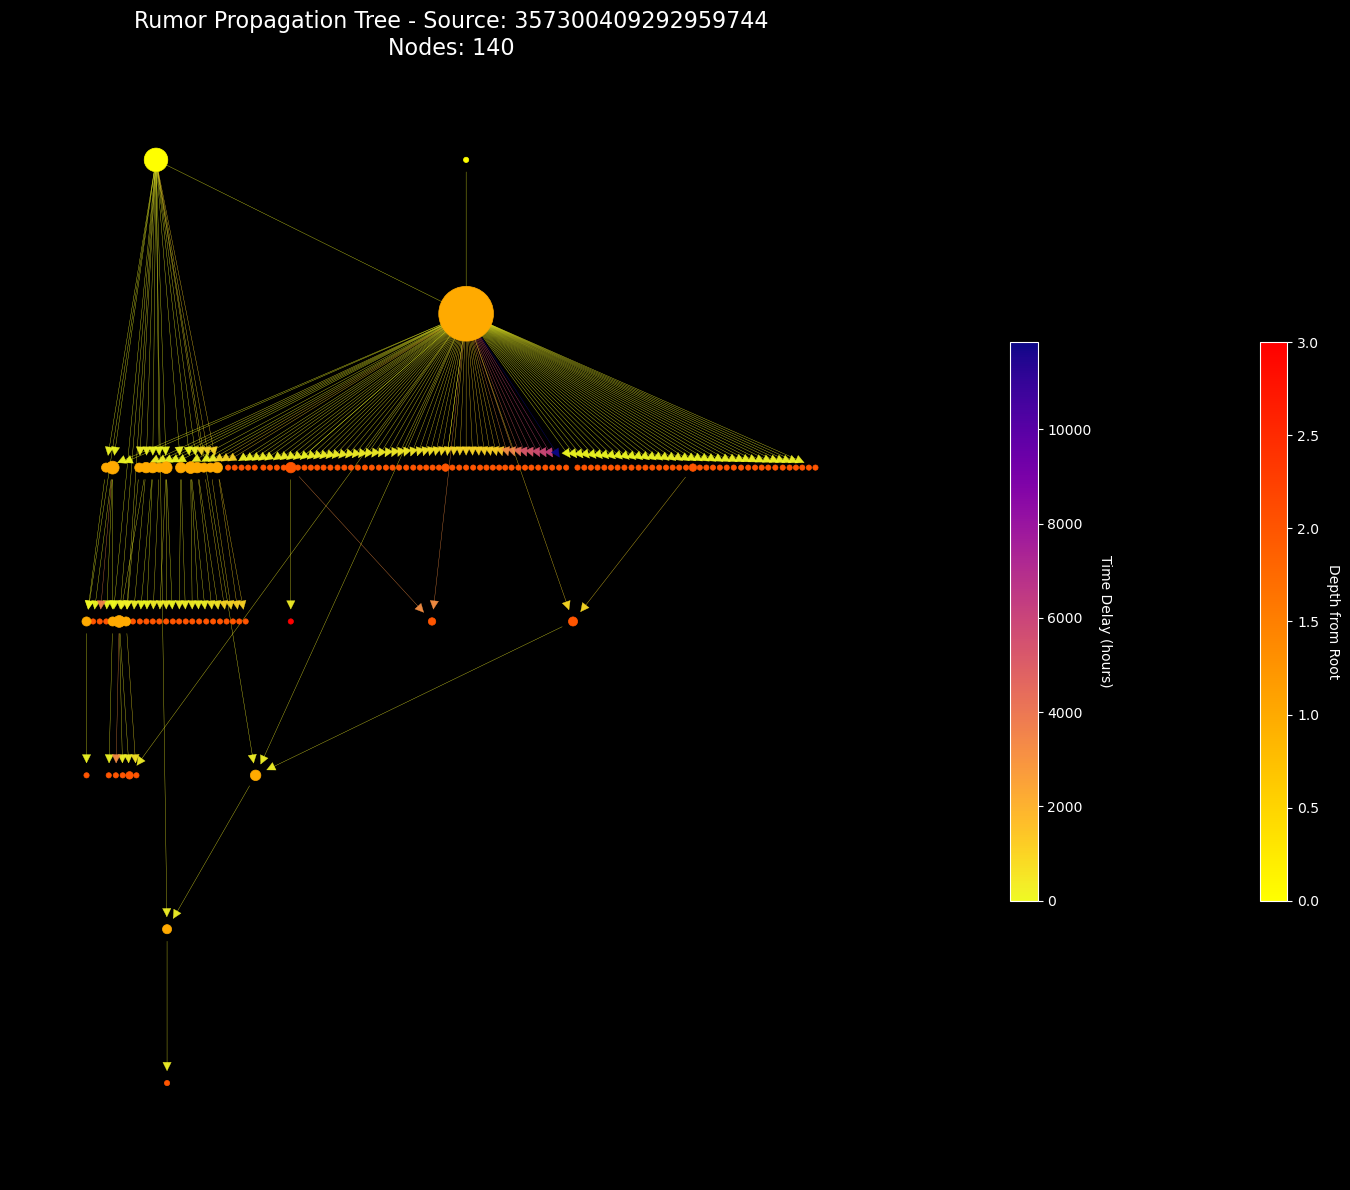

In [5]:
G,root_id = load_rumour('357300409292959744.txt')
plot_tree(G,root_id)

## Simple GCN Baseline Code

In [6]:

import torch
from torch_geometric.utils import from_networkx
from torch_geometric.nn import GCNConv
def convert_to_embedding(G):
    print("Converting NetworkX graph to PyTorch Geometric...")
    # Normalize node attributes - make sure all nodes have the same keys
    default_attrs = {'delay': 0.0, 'depth': 0}
    for node in G.nodes():
        for key, value in default_attrs.items():
            if key not in G.nodes[node]:
                G.nodes[node][key] = value
    # Optional: Remove extra attributes that may cause inconsistency (e.g., 'label')
    for node in G.nodes():
        if 'label' in G.nodes[node]:
            del G.nodes[node]['label']  # remove inconsistent 'label'
    # Convert to PyG Data
    data = from_networkx(G)
    #Add node features (degree is always consistent)
    degree = np.array([G.degree(n) for n in G.nodes()], dtype=np.float32)
    data.x = torch.tensor(degree.reshape(-1, 1), dtype=torch.float)
    if 'delay' in G.edges[list(G.edges())[0]]:
        edge_attrs = [G[u][v]['delay'] for u, v in G.edges()]
        data.edge_attr = torch.tensor(edge_attrs, dtype=torch.float).reshape(-1, 1)
    
    print("PyG Data ready:")
    print(f"  - Nodes: {data.num_nodes}")
    print(f"  - Edges: {data.num_edges}")
    print(f"  - Node features shape: {data.x.shape}")
    print(f"  - Edge attributes shape: {data.edge_attr.shape if hasattr(data, 'edge_attr') else 'none'}")
    # Simple GCN model
    class SimpleGCN(torch.nn.Module):
        def __init__(self, in_channels=1, hidden_channels=32, out_channels=16):
            super().__init__()
            self.conv1 = GCNConv(in_channels, hidden_channels)
            self.conv2 = GCNConv(hidden_channels, out_channels)
    
        def forward(self, data):
            x, edge_index = data.x, data.edge_index
            x = self.conv1(x, edge_index).relu()
            x = self.conv2(x, edge_index)
            return x
    
    # Run forward pass (no training)
    model = SimpleGCN()
    model.eval()
    
    with torch.no_grad():
        embeddings = model(data)
    
    print("GCN Node Embeddings:")
    print(f"  Shape: {embeddings.shape}")
    print(f"  First node embedding (first 5 values): {embeddings[0][:5]}")
    return embeddings

In [7]:
embeddings = convert_to_embedding(G)
print(embeddings)

Converting NetworkX graph to PyTorch Geometric...
PyG Data ready:
  - Nodes: 140
  - Edges: 164
  - Node features shape: torch.Size([140, 1])
  - Edge attributes shape: torch.Size([164, 1])
GCN Node Embeddings:
  Shape: torch.Size([140, 16])
  First node embedding (first 5 values): tensor([ 2.7707, -0.1530,  1.4423, -8.7112, -3.5271])
tensor([[ 2.7707e+00, -1.5305e-01,  1.4423e+00,  ...,  2.1973e+00,
         -5.6940e+00, -3.1087e+00],
        [ 1.3854e-01, -7.6523e-03,  7.2115e-02,  ...,  1.0986e-01,
         -2.8470e-01, -1.5543e-01],
        [ 5.3361e+00, -2.9475e-01,  2.7777e+00,  ...,  4.2317e+00,
         -1.0966e+01, -5.9870e+00],
        ...,
        [ 3.8411e+00, -2.1217e-01,  1.9995e+00,  ...,  3.0462e+00,
         -7.8938e+00, -4.3096e+00],
        [ 3.8411e+00, -2.1217e-01,  1.9995e+00,  ...,  3.0462e+00,
         -7.8938e+00, -4.3096e+00],
        [ 3.8411e+00, -2.1217e-01,  1.9995e+00,  ...,  3.0462e+00,
         -7.8938e+00, -4.3096e+00]])


### DQN BaseLine

In [10]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import torch
from stable_baselines3 import DQN
import networkx as nx
from stable_baselines3.common.env_util import make_vec_env
from networkx.drawing.nx_pydot import graphviz_layout  # optional for plot
from stable_baselines3.common.logger import configure
#──────────────────────────────────────

class DynamicRumorEnv(gym.Env):
    """
    Dynamic RL environment for rumor mitigation.
    - Starts with only root infected
    - Spreads step-by-step based on real edge delays
    - Agent can block nodes to stop future infections
    """
    def __init__(self, G, root_id):
        super().__init__()
        self.G = G.copy()          # don't modify original
        self.root_id = root_id
        
        # State: [infected_count, current_time, step_count]
        self.observation_space = spaces.Box(low=0, high=np.inf, shape=(3,), dtype=np.float32)
        # Action: 0 = do nothing, 1–10 = block one of 10 random infected nodes
        self.action_space = spaces.Discrete(11)
        # Prepare events: (delay, parent, child)
        self.events = [(d['delay'], u, v) for u, v, d in G.edges(data=True)]
        self.events.sort()  # sort by time
        #rewards: -(number of infected node)-(cost of blocking)
        self.reset()

    def reset(self, seed=None, options=None):
        self.infected = {self.root_id}
        self.blocked = set()
        self.current_time = 0.0
        self.step_count = 0
        self.event_idx = 0
        self.done = False
        
        return self._get_obs(), {}

    def _get_obs(self):
        return np.array([
            len(self.infected),
            self.current_time,
            float(self.step_count)
        ], dtype=np.float32)

    def step(self, action):
        reward = 0.0
        
        # Block action (1–10 = block a random infected node)
        if action > 0 and self.infected:
            to_block = np.random.choice(list(self.infected))
            self.blocked.add(to_block)
            self.infected.discard(to_block)
            reward -= 0.5  # cost of blocking

        # Simulate spread: process all events up to current time
        new_infected = 0
        while self.event_idx < len(self.events) and self.events[self.event_idx][0] <= self.current_time:
            delay, parent, child = self.events[self.event_idx]
            self.event_idx += 1
            
            if parent in self.infected and child not in self.infected and child not in self.blocked:
                self.infected.add(child)
                new_infected += 1

        reward -= new_infected  # penalty for spread
        
        self.current_time += 1.0  # advance 1 hour per step
        self.step_count += 1

        # End conditions
        terminated = len(self.infected) == 0 or self.event_idx >= len(self.events)
        truncated = self.step_count >= 30
        self.done = terminated or truncated

        obs = self._get_obs()
        return obs, reward, terminated, truncated, {}

# ────────────────────────────────────────────────
# Training & Evaluation
# ────────────────────────────────────────────────

# Create environment (use raw env for simplicity)
env = DynamicRumorEnv(G, root_id)

# DQN model
model = DQN(
    policy="MlpPolicy",
    env=env,
    learning_rate=0.001,
    buffer_size=10000,
    learning_starts=500,
    batch_size=32,
    tau=1.0,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1000,
    exploration_fraction=0.2,
    exploration_final_eps=0.05,
    verbose=0,
    device='cpu'
)
log_dir = "logs/dqn"
os.makedirs(log_dir, exist_ok=True)
new_logger = configure(log_dir, ["stdout", "csv", "tensorboard"])
# Attach logger to model
model.set_logger(new_logger)
print("Starting DQN training...")
model.learn(total_timesteps=20000, progress_bar=True)
print("Training finished!")

#model.save("dqn_rumor_agent")

Logging to logs/dqn


Output()

Starting DQN training...
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1        |
|    ep_rew_mean      | -0.5     |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 189      |
|    time_elapsed     | 0        |
|    total_timesteps  | 4        |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1        |
|    ep_rew_mean      | -0.5     |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 309      |
|    time_elapsed     | 0        |
|    total_timesteps  | 8        |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1        |
|    ep_rew_mean      | -0.5     |
|    exploration_rate | 0.997    |
| time/               |       

Training finished!


In [11]:
def run_episode(model, env, render=False):
    obs, _ = env.reset()
    done = False
    total_reward = 0
    infected_over_time = [1]  # root
    steps = [0]
    
    while not done:
        if model is None:
            action = env.action_space.sample()
        else:
            action, _ = model.predict(obs, deterministic=True)
        
        obs, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        total_reward += reward
        
        infected_over_time.append(len(env.infected))
        steps.append(steps[-1] + 1)
        
        if render:
            print(f"Step {steps[-1]} | Infected: {len(env.infected)} | Reward: {reward}")
    
    return steps, infected_over_time, total_reward

# Run multiple episodes
n_episodes = 20
random_rewards = []
trained_rewards = []
random_histories = []
trained_histories = []

print("\nEvaluating agents...")
for _ in range(n_episodes):
    steps_r, infected_r, rew_r = run_episode(None, env)
    random_rewards.append(rew_r)
    random_histories.append((steps_r, infected_r))
    
    steps_t, infected_t, rew_t = run_episode(model, env)
    trained_rewards.append(rew_t)
    trained_histories.append((steps_t, infected_t))


Evaluating agents...


In [32]:
from stable_baselines3.common.logger import configure
from tqdm import tqdm
tqdm._instances.clear()  # clear any stuck tqdm instances
# Convert embeddings to numpy for easier use
embeddings_np = embeddings.detach().cpu().numpy()  # shape [num_nodes, 16]

# Create node ID to index mapping (important!)
node_list = list(G.nodes())
node_to_idx = {node: i for i, node in enumerate(node_list)}

class GCN_DQN_Env(gym.Env):
    """
    DQN environment using GCN embeddings in state.
    Agent sees: mean graph embedding + infected count + time
    """
    def __init__(self, G, root_id, embeddings_np, node_to_idx):
        super().__init__()
        self.G = G.copy()
        self.root_id = root_id
        self.embeddings = embeddings_np
        self.node_to_idx = node_to_idx
        # Prepare sorted events
        self.events = [(d['delay'], u, v) for u, v, d in G.edges(data=True)]
        self.events.sort(key=lambda x: x[0])  # sort by time
        self.event_idx = 0
        
        # State: [mean_embedding (16), infected_count, time_step]
        state_dim = 16 + 1 + 1
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(state_dim,), dtype=np.float32)
        
        # Action: 0 = do nothing, 1–10 = block one of top-10 infected nodes
        self.action_space = spaces.Discrete(11)
        #rewards : -(number of infected node)-(cost of blocking)
        self.reset()

    def reset(self, seed=None, options=None):
        self.infected = {self.root_id}
        self.blocked = set()
        self.current_time = 0.0
        self.step_count = 0
        self.done = False
        
        return self._get_obs(), {}

    def _get_obs(self):
        # Mean embedding of all nodes (simple global state)
        # You can improve: mean of infected nodes only
        mean_emb = np.mean(self.embeddings, axis=0)  # shape (16,)
        
        state = np.concatenate([
            mean_emb,
            [len(self.infected)],
            [self.current_time]
        ]).astype(np.float32)
        
        return state

    def step(self, action):
        reward = 0.0
    
        if action > 0 and len(self.infected) > 1: # Only block if spread has started
            # Filter out the root so we target the 'spreaders' instead
            candidates = [n for n in self.infected if n != self.root_id]
            if candidates:
                # Logic: Action 1 targets 1st candidate, Action 2 targets 2nd, etc.
                idx = min(action - 1, len(candidates) - 1)
                to_block = candidates[idx]
                
                self.blocked.add(to_block)
                self.infected.discard(to_block)
                reward -= 0.8 # Cost of blocking
                print(f"Strategic Block: {to_block}")
    
        # Spread simulation: process all events that are due now
        new_infected = 0
        while self.event_idx < len(self.events) and self.events[self.event_idx][0] <= self.current_time:
            delay, parent, child = self.events[self.event_idx]
            self.event_idx += 1
            
            # Infect child if parent is infected and child not blocked
            if parent in self.infected and child not in self.infected and child not in self.blocked:
                self.infected.add(child)
                new_infected += 1
                print(f"→ Infected {child} from {parent} at t={self.current_time:.1f}")
    
        reward -= 2.0 * new_infected  # strong penalty for spread
    
        # Small survival bonus so reward isn't always zero
        reward += 0.1
    
        self.current_time += 1.0
        self.step_count += 1
    
        terminated = len(self.infected) == 0 or self.event_idx >= len(self.events)
        truncated = self.step_count >= 50  # max episode length
        done = terminated or truncated
    
        obs = self._get_obs()
        return obs, reward, terminated, truncated, {}
# ────────────────────────────────────────────────
# Create & Train
# ────────────────────────────────────────────────

env_g = GCN_DQN_Env(G, root_id, embeddings_np, node_to_idx)

model_g = DQN(
    "MlpPolicy",
    env_g,
    learning_rate=0.0005,
    buffer_size=20000,
    learning_starts=1000,
    batch_size=64,
    tau=0.005,
    gamma=0.99,
    train_freq=4,
    gradient_steps=1,
    target_update_interval=1000,
    exploration_fraction=0.3,
    exploration_final_eps=0.02,
    verbose=1
)
log_dir = "logs/dqn/gcn"
os.makedirs(log_dir, exist_ok=True)

# Configure logger (saves to CSV, stdout, TensorBoard)
new_logger = configure(log_dir, ["stdout", "csv", "tensorboard"])

# Attach logger to model
model_g.set_logger(new_logger)
print("Starting DQN training with logging...")
model_g.learn(
    total_timesteps=20000,       # increase if needed
    progress_bar=True,
    log_interval=10              # print every 10 episodes
)

print("Training finished!")

# Quick test
obs = env_g.reset()[0]
done = False
total_reward = 0
while not done:
    action, _ = model_g.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, _ = env_g.step(action)
    done = terminated or truncated
    total_reward += reward
    print(f"Reward: {reward:.2f} | Infected: {len(env_g.infected)}")

print(f"Final total reward: {total_reward}")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to logs/dqn/gcn


Output()

→ Infected 24304852 from 357300409292959744 at t=0.0

Strategic Block: 24304852

→ Infected 63889852 from 357300409292959744 at t=8.0

...

Strategic Block: 37493475

→ Infected 14095664 from 357300409292959744 at t=44.0

Strategic Block: 14095664

Starting DQN training with logging...
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 50       |
|    ep_rew_mean      | 3.04     |
|    exploration_rate | 0.918    |
| time/               |          |
|    episodes         | 10       |
|    fps              | 4875     |
|    time_elapsed     | 0        |
|    total_timesteps  | 500      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 50       |
|    ep_rew_mean      | 4.02     |
|    exploration_rate | 0.837    |
| time/               |          |
|    episodes         | 20       |
|    fps              | 3946     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1000     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 50       |
|    ep_rew_mean      | 4.35     |
|    exploration_rate | 0.755    |
| time/          

Training finished!
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0.10 | Infected: 1
Reward: 0

In [33]:
# Run multiple episodes
n_episodes = 20
random_rewards_g = []
trained_rewards_g = []
random_histories_g = []
trained_histories_g = []

print("\nEvaluating agents...")
for _ in range(n_episodes):
    steps_r, infected_r, rew_r = run_episode(None, env_g)
    random_rewards_g.append(rew_r)
    random_histories_g.append((steps_r, infected_r))
    
    steps_t, infected_t, rew_t = run_episode(model_g, env_g)
    trained_rewards_g.append(rew_t)
    trained_histories_g.append((steps_t, infected_t))


Evaluating agents...


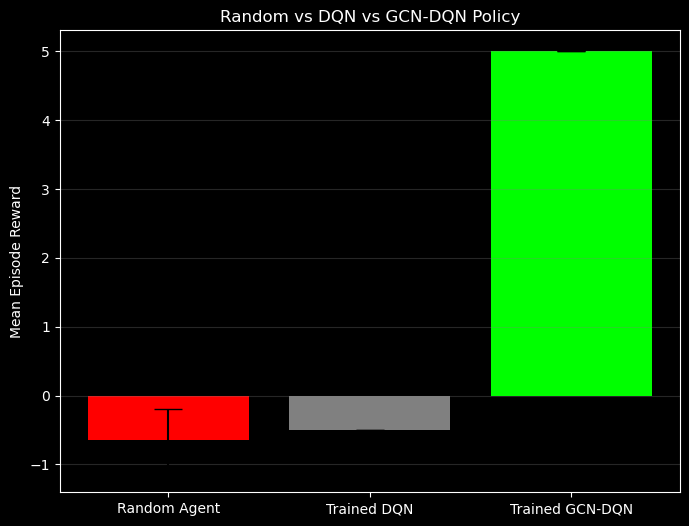

In [20]:
# ────────────────────────────────────────────────
# Visualization 1: Reward Comparison Bar Chart
# ────────────────────────────────────────────────

plt.figure(figsize=(8, 6), facecolor='black')
plt.style.use('dark_background')
plt.bar(["Random Agent","Trained DQN", "Trained GCN-DQN"], 
        [np.mean(random_rewards),np.mean(trained_rewards), np.mean(trained_rewards_g)], 
        yerr=[np.std(random_rewards),np.std(trained_rewards), np.std(trained_rewards_g)], 
        color=['red','gray', 'lime'], capsize=10)
plt.ylabel("Mean Episode Reward", color='white')
plt.title("Random vs DQN vs GCN-DQN Policy", color='white')
plt.grid(axis='y', alpha=0.3, color='gray')
plt.tick_params(colors='white')
#plt.savefig("plots/dqn_reward_comparison.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.show()

Hello


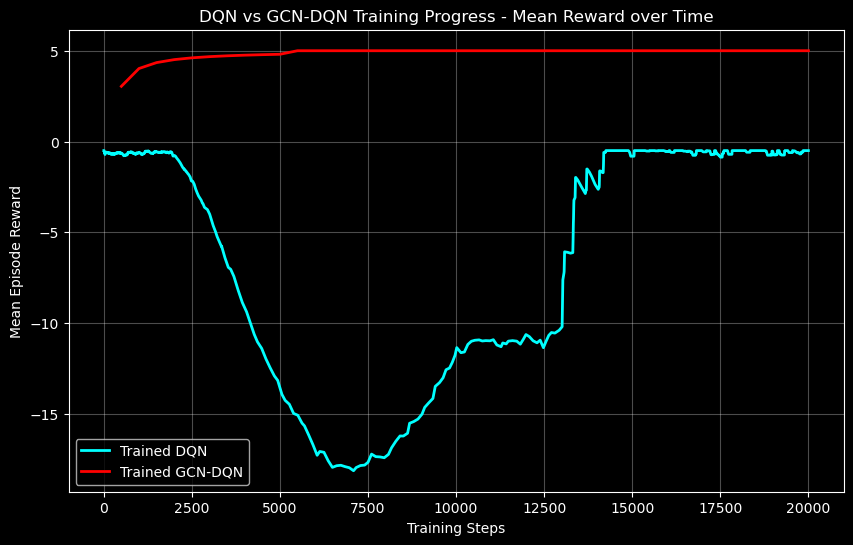

In [34]:
from stable_baselines3.common.logger import configure

# Re-run training with logging (or use existing logs)
#model.set_logger(configure("logs/", ["stdout", "csv", "tensorboard"]))
#model.learn(total_timesteps=20000)

# Plot rewards from CSV log (Stable Baselines saves it automatically)
import pandas as pd
log_file = "logs/dqn/progress.csv"  # or find the latest csv in logs/
if os.path.exists(log_file):
    df = pd.read_csv(log_file)
    print("Hello")
log_file_g = "logs/dqn/gcn/progress.csv"  # or find the latest csv in logs/
if os.path.exists(log_file_g):
    df_g = pd.read_csv(log_file_g)
plt.figure(figsize=(10, 6))
plt.plot(df['time/total_timesteps'], df['rollout/ep_rew_mean'], color='cyan', linewidth=2,label = "Trained DQN")
plt.plot(df_g['time/total_timesteps'], df_g['rollout/ep_rew_mean'], color='red', linewidth=2,label="Trained GCN-DQN")
plt.xlabel("Training Steps")
plt.ylabel("Mean Episode Reward")
plt.title("DQN vs GCN-DQN Training Progress - Mean Reward over Time")
plt.grid(True, alpha=0.3)
plt.legend()
#plt.savefig("plots/dqn_reward_curve.png", dpi=300, bbox_inches='tight', facecolor='black')
plt.show()